# Урок 15.18. Теория графов: вершины, рёбра, деревья

**Интерактивная версия:** `lessons/lesson_15_18/web/index.html`

После урока вы сможете:

* описывать задачи графами, считать степени и проверять степенные последовательности;
* хранить графы в матрицах и CSR, различать изоморфные графы, проверять связность и двудольность;
* писать BFS, DFS, Дейкстру, A*, Беллмана — Форда и Флойда и сверять их со `scipy.sparse.csgraph`;
* работать с деревьями: код Прюфера, формула Кэли, теорема Кирхгофа, дерево решений как граф;
* строить остовные деревья, топологический порядок, критический путь, сильно связные компоненты;
* раскрашивать графы, искать паросочетания и потоки;
* считать маршруты, PageRank, центральности и спектр лапласиана;
* строить графовые признаки для бустинга без утечки и проверять взаимодействия признаков.

Ноутбук повторяет восемь блоков урока; каждый блок заканчивается сверкой с библиотекой.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import heapq
from collections import deque
from itertools import permutations, product
from math import comb, factorial, log

import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import (connected_components, dijkstra, floyd_warshall, maximum_bipartite_matching,
                                  maximum_flow, minimum_spanning_tree, bellman_ford)

from gbcourse import GBClassifier, GBRegressor
from gbcourse.datasets import friedman1
from gbcourse.metrics import roc_auc
from gbcourse.plotting import use_course_style
from gbcourse.rng import Mulberry32
from gbcourse.style import BLUE, INK, MUTED, ORANGE, SERIES

use_course_style()


def draw(ax, pos, edges, labels=None, colors=None, highlight=(), title=None, directed=False, size=320):
    """Нарисовать граф: pos — {вершина: (x, y)}, edges — пары, highlight — рёбра другим цветом."""
    hl = {frozenset(e) if not directed else tuple(e) for e in highlight}
    for a, b in edges:
        key = frozenset((a, b)) if not directed else (a, b)
        c, w = (ORANGE, 3) if key in hl else (MUTED, 1.6)
        if directed:
            ax.annotate("", xy=pos[b], xytext=pos[a], arrowprops=dict(arrowstyle="-|>", color=c, lw=w, shrinkA=11, shrinkB=11))
        else:
            ax.plot(*zip(pos[a], pos[b]), color=c, lw=w, zorder=1)
    vs = list(pos)
    ax.scatter([pos[v][0] for v in vs], [pos[v][1] for v in vs], s=size, zorder=2,
               c=[colors.get(v, BLUE) if colors else BLUE for v in vs], edgecolors="white", linewidths=1.5)
    for v in vs:
        ax.text(*pos[v], labels[v] if labels else str(v), ha="center", va="center", color="white", fontsize=9, fontweight="bold", zorder=3)
    ax.set_aspect("equal")
    ax.axis("off")
    if title:
        ax.set_title(title)

## Блок 1. Язык графов

### 1.1. Степени и лемма о рукопожатиях

Каждое ребро добавляет единицу к степеням двух вершин: $\sum_v \deg v = 2|E|$. Проверим на мостах
Кёнигсберга и на семействах графов из шага 2.

In [2]:
def degrees(edges):
    d = {}
    for a, b in edges:
        d[a] = d.get(a, 0) + 1
        d[b] = d.get(b, 0) + 1
    return d


konig = [("A", "B"), ("A", "B"), ("A", "C"), ("A", "C"), ("A", "D"), ("B", "D"), ("C", "D")]
for name, E in (("Кёнигсберг", konig), ("+ мост B–C", konig + [("B", "C")])):
    d = degrees(E)
    odd = [v for v, k in d.items() if k % 2]
    verdict = "цикл" if not odd else "путь" if len(odd) == 2 else "обхода нет"
    print(f"{name}: степени {d}, нечётных {len(odd)} → {verdict}; сумма степеней {sum(d.values())} = 2·{len(E)}")

K = lambda n: [(i, j) for i in range(n) for j in range(i + 1, n)]
Q = lambda d: [(b, b | (1 << k)) for b in range(2 ** d) for k in range(d) if not b & (1 << k)]
grid = lambda m, n: [(r * n + c, r * n + c + 1) for r in range(m) for c in range(n - 1)] + [(r * n + c, (r + 1) * n + c) for r in range(m - 1) for c in range(n)]
for name, E, formula in (("K6", K(6), comb(6, 2)), ("Q4", Q(4), 4 * 2 ** 3), ("решётка 3×4", grid(3, 4), 3 * 3 + 4 * 2)):
    d = degrees(E)
    assert sum(d.values()) == 2 * len(E) and len(E) == formula
    print(f"{name}: рёбер {len(E)} (формула {formula}), степени {sorted(set(d.values()))}")

Кёнигсберг: степени {'A': 5, 'B': 3, 'C': 3, 'D': 3}, нечётных 4 → обхода нет; сумма степеней 14 = 2·7
+ мост B–C: степени {'A': 5, 'B': 4, 'C': 4, 'D': 3}, нечётных 2 → путь; сумма степеней 16 = 2·8
K6: рёбер 15 (формула 15), степени [5]
Q4: рёбер 32 (формула 32), степени [4]
решётка 3×4: рёбер 17 (формула 17), степени [2, 3, 4]


### 1.2. Алгоритм Гавела — Хакими

Чётность суммы — необходимое условие. Достаточное даёт жадный алгоритм: вершину наибольшей степени
соединяем с вершинами следующих по величине степеней.

In [3]:
def havel_hakimi(seq):
    res = list(seq)
    if sum(res) % 2:
        return None
    n, edges = len(res), []
    while True:
        order = sorted((i for i in range(n) if res[i] > 0), key=lambda i: (-res[i], i))
        if not order:
            return edges
        v, d = order[0], res[order[0]]
        if len(order) - 1 < d:
            return None
        res[v] = 0
        for u in order[1:d + 1]:
            res[u] -= 1
            edges.append((v + 1, u + 1))


for seq in ([4, 3, 3, 2, 2], [4, 4, 4, 1, 1], [3] * 9, [3] * 10):
    E = havel_hakimi(seq)
    print(seq, "→", "графа нет" if E is None else f"граф из {len(E)} рёбер: {E}")
assert havel_hakimi([4, 4, 4, 1, 1]) is None and len(havel_hakimi([3] * 10)) == 15

[4, 3, 3, 2, 2] → граф из 7 рёбер: [(1, 2), (1, 3), (1, 4), (1, 5), (2, 3), (2, 4), (3, 5)]
[4, 4, 4, 1, 1] → графа нет
[3, 3, 3, 3, 3, 3, 3, 3, 3] → графа нет
[3, 3, 3, 3, 3, 3, 3, 3, 3, 3] → граф из 15 рёбер: [(1, 2), (1, 3), (1, 4), (5, 6), (5, 7), (5, 8), (9, 10), (9, 2), (9, 3), (4, 6), (4, 7), (8, 10), (8, 2), (3, 6), (7, 10)]


### 1.3. Хранение: матрица смежности и CSR

Граф A–B, A–C, B–C, C–D в формате CSR: соседи вершины $i$ — `indices[indptr[i]:indptr[i+1]]`.

In [4]:
A = np.zeros((4, 4), dtype=int)
for a, b in [(0, 1), (0, 2), (1, 2), (2, 3)]:
    A[a, b] = A[b, a] = 1
M = csr_matrix(A)
print("indptr :", M.indptr, "\nindices:", M.indices)
print("соседи C:", M.indices[M.indptr[2]:M.indptr[3]], " степени:", np.diff(M.indptr))
n, avg = 10 ** 6, 10
print(f"память для n = 10^6, средняя степень 10: матрица {n * n / 8 / 1e9:.0f} ГБ, CSR {(8 * (n + 1) + 4 * n * avg) / 1e6:.0f} МБ")

indptr : [0 2 4 7 8] 
indices: [1 2 0 2 0 1 3 2]
соседи C: [0 1 3]  степени: [2 2 3 1]
память для n = 10^6, средняя степень 10: матрица 125 ГБ, CSR 48 МБ


### 1.4. Изоморфизм и инварианты

Инварианты (степени, треугольники, компоненты) доказывают различие; одинаковость доказывает нумерация.
Перебором считаем автоморфизмы куба и сравниваем $K_{3,3}$ с призмой.

In [5]:
def adj_sets(n, E):
    S = [set() for _ in range(n)]
    for a, b in E:
        S[a].add(b)
        S[b].add(a)
    return S


def triangles(n, E):
    S = adj_sets(n, E)
    return sum(1 for i in range(n) for j in S[i] for k in S[j] if i < j < k and k in S[i])


def count_isomorphisms(n, E1, E2):
    S2 = {frozenset(e) for e in E2}
    return sum(all(frozenset((p[a], p[b])) in S2 for a, b in E1) for p in permutations(range(n))) if len(E1) == len(E2) else 0


cube_a = [(0, 1), (1, 2), (2, 3), (3, 0), (4, 5), (5, 6), (6, 7), (7, 4), (0, 4), (1, 5), (2, 6), (3, 7)]
cube_b = [(i, (i + 1) % 8) for i in range(8)] + [(0, 3), (1, 6), (2, 5), (4, 7)]
k33 = [(i, 3 + j) for i in range(3) for j in range(3)]
prism = [(0, 1), (1, 2), (2, 0), (3, 4), (4, 5), (5, 3), (0, 3), (1, 4), (2, 5)]
print("куб двумя способами — изоморфизмов:", count_isomorphisms(8, cube_a, cube_b))
print("K33 и призма — изоморфизмов:", count_isomorphisms(6, k33, prism), "; треугольников:", triangles(6, k33), "и", triangles(6, prism))
assert count_isomorphisms(8, cube_a, cube_b) == 48 and count_isomorphisms(6, k33, prism) == 0

куб двумя способами — изоморфизмов: 48
K33 и призма — изоморфизмов: 0 ; треугольников: 0 и 2


### 1.5. Связность, циклы, двудольность

Один обход BFS находит компоненты, а раскраска уровней через один проверяет двудольность.
Цикломатическое число $|E| - |V| + k$ — число независимых циклов.

In [6]:
def components_and_bipartite(n, E):
    S = adj_sets(n, E)
    comp, color, k, bip = [-1] * n, [-1] * n, 0, True
    for s in range(n):
        if comp[s] >= 0:
            continue
        comp[s], color[s], q = k, 0, deque([s])
        while q:
            v = q.popleft()
            for u in S[v]:
                if comp[u] < 0:
                    comp[u], color[u] = k, 1 - color[v]
                    q.append(u)
                elif color[u] == color[v]:
                    bip = False
        k += 1
    return k, bip


for name, n, E in (("C6", 6, [(i, (i + 1) % 6) for i in range(6)]), ("C5", 5, [(i, (i + 1) % 5) for i in range(5)]),
                   ("два треугольника", 6, [(0, 1), (1, 2), (2, 0), (3, 4), (4, 5), (5, 3)]), ("K33", 6, k33)):
    k, bip = components_and_bipartite(n, E)
    print(f"{name:18} компонент {k}, независимых циклов {len(E) - n + k}, двудольный: {bip}")

C6                 компонент 1, независимых циклов 1, двудольный: True
C5                 компонент 1, независимых циклов 1, двудольный: False
два треугольника   компонент 2, независимых циклов 2, двудольный: False
K33                компонент 1, независимых циклов 4, двудольный: True


### 1.6. Эйлеров путь (Хирхольцер) и коды де Брёйна

Орграф на словах длины 2 с рёбрами-словами длины 3: у каждой вершины входящая степень равна
исходящей, и эйлеров цикл даёт строку, содержащую все 8 двоичных троек.

In [7]:
def hierholzer(adj, start):
    adj = {v: list(nb) for v, nb in adj.items()}
    stack, out = [start], []
    while stack:
        v = stack[-1]
        if adj[v]:
            stack.append(adj[v].pop())
        else:
            out.append(stack.pop())
    return out[::-1]


nodes = ["".join(p) for p in product("01", repeat=2)]
adj = {v: [v[1] + c for c in "10"] for v in nodes}
cycle = hierholzer(adj, "00")
seq = cycle[0] + "".join(v[1] for v in cycle[1:])
triples = {seq[i:i + 3] for i in range(len(seq) - 2)}
print("эйлеров цикл:", " → ".join(cycle))
print("строка де Брёйна:", seq, "— троек:", len(triples))
assert len(triples) == 8 and len(seq) == 10

эйлеров цикл: 00 → 00 → 01 → 10 → 01 → 11 → 11 → 10 → 00
строка де Брёйна: 0001011100 — троек: 8


### 1.7. Коммивояжёр: перебор против эвристик

Число циклов $(n-1)!/2$ растёт быстрее экспоненты. Сравним точный ответ с «ближайшим соседом» и 2-opt
на тех же 9 городах, что и в виджете (тот же генератор и то же зерно).

In [8]:
rng = Mulberry32(3)
cities = []
while len(cities) < 9:
    c = (round(rng.uniform(40, 480)), round(rng.uniform(40, 260)))
    if all(np.hypot(c[0] - q[0], c[1] - q[1]) >= 55 for q in cities):
        cities.append(c)
Dm = np.array([[np.hypot(a[0] - b[0], a[1] - b[1]) / 10 for b in cities] for a in cities])
length = lambda t: sum(Dm[t[i], t[(i + 1) % len(t)]] for i in range(len(t)))
best = min(((0,) + p for p in permutations(range(1, 9))), key=length)
tour, left = [0], set(range(1, 9))
while left:
    nxt = min(left, key=lambda u: Dm[tour[-1], u])
    tour.append(nxt)
    left.remove(nxt)
nn_len = length(tour)
improved = True
while improved:
    improved = False
    for i in range(1, 8):
        for j in range(i + 1, 9):
            a, b, c, d = tour[i - 1], tour[i], tour[j], tour[(j + 1) % 9]
            if Dm[a, c] + Dm[b, d] < Dm[a, b] + Dm[c, d] - 1e-9:
                tour[i:j + 1] = tour[i:j + 1][::-1]
                improved = True
print(f"перебор {length(best):.2f}, ближайший сосед {nn_len:.2f} (+{nn_len / length(best) - 1:.1%}), 2-opt {length(tour):.2f}")
print("число циклов (n−1)!/2:", {n: factorial(n - 1) // 2 for n in (5, 9, 10, 20)})

перебор 90.81, ближайший сосед 96.14 (+5.9%), 2-opt 95.17
число циклов (n−1)!/2: {5: 12, 9: 20160, 10: 181440, 20: 60822550204416000}


## Блок 2. Обходы и кратчайшие пути

### 2.1. BFS и DFS

BFS идёт волнами и даёт кратчайшие пути по числу рёбер; DFS идёт вглубь.

In [9]:
G = {"A": "BCD", "B": "AEF", "C": "ADG", "D": "ACH", "E": "BI", "F": "BI", "G": "CJ", "H": "DJ", "I": "EF", "J": "GH"}


def bfs(start):
    dist, order, q = {start: 0}, [], deque([start])
    while q:
        v = q.popleft()
        order.append(v)
        for u in G[v]:
            if u not in dist:
                dist[u] = dist[v] + 1
                q.append(u)
    return order, dist


def dfs(start):
    seen, order, stack = set(), [], [start]
    while stack:
        v = stack.pop()
        if v in seen:
            continue
        seen.add(v)
        order.append(v)
        stack.extend(u for u in reversed(G[v]) if u not in seen)
    return order


order, dist = bfs("A")
print("BFS:", "".join(order), " расстояния:", dist)
print("DFS:", "".join(dfs("A")))
assert "".join(order) == "ABCDEFGHIJ" and "".join(dfs("A")) == "ABEIFCDHJG" and dist["J"] == 3

BFS: ABCDEFGHIJ  расстояния: {'A': 0, 'B': 1, 'C': 1, 'D': 1, 'E': 2, 'F': 2, 'G': 2, 'H': 2, 'I': 3, 'J': 3}
DFS: ABEIFCDHJG


### 2.2. Мосты и точки сочленения (Тарьян)

Ребро дерева DFS $v \to u$ — мост, если $\mathrm{low}(u) > \mathrm{вход}(v)$; вершина — точка
сочленения, если $\mathrm{low}(u) \ge \mathrm{вход}(v)$.

In [10]:
sys.setrecursionlimit(10_000)
edges_dfs = [(1, 2), (2, 3), (3, 4), (4, 1), (1, 3), (3, 5), (5, 6), (6, 7), (7, 5), (7, 8), (8, 9), (9, 7), (9, 10)]
adj = {}
for a, b in edges_dfs:
    adj.setdefault(a, []).append(b)
    adj.setdefault(b, []).append(a)
tin, low, timer, bridges, cut, back = {}, {}, [0], [], set(), [0]


def tarjan(v, parent):
    timer[0] += 1
    tin[v] = low[v] = timer[0]
    children = 0
    for u in sorted(adj[v]):
        if u == parent:
            continue
        if u not in tin:
            children += 1
            tarjan(u, v)
            low[v] = min(low[v], low[u])
            if low[u] > tin[v]:
                bridges.append((v, u))
            if parent is not None and low[u] >= tin[v]:
                cut.add(v)
        elif tin[u] < tin[v]:
            back[0] += 1
            low[v] = min(low[v], tin[u])
    if parent is None and children > 1:
        cut.add(v)
    timer[0] += 1


tarjan(1, None)
print("мосты:", bridges, " точки сочленения:", sorted(cut), " обратных рёбер:", back[0], "= |E| − |V| + 1 =", len(edges_dfs) - 10 + 1)
assert sorted(bridges) == [(3, 5), (9, 10)] and sorted(cut) == [3, 5, 7, 9]

мосты: [(9, 10), (3, 5)]  точки сочленения: [3, 5, 7, 9]  обратных рёбер: 4 = |E| − |V| + 1 = 4


### 2.3. Лабиринт: BFS, Дейкстра и A*

Тот же лабиринт, что в виджете: болото стоит 5. BFS ищет наименьшее число шагов, Дейкстра и A* —
наименьшую стоимость; A* раскрывает меньше клеток благодаря допустимой эвристике.

In [11]:
maze = [".....#............", ".....#............", ".....#....~~~~~...", ".....#....~~~~~...", ".....#....~~~~~...",
        ".S........~~~~~.G.", ".....#....~~~~~...", ".....#....~~~~~...", ".....#....~~~~~...", ".....#............", ".....#............"]
Hm, Wm = len(maze), len(maze[0])
find = lambda ch: next((y, x) for y in range(Hm) for x in range(Wm) if maze[y][x] == ch)
start, goal = find("S"), find("G")
cost = lambda c: 5 if maze[c[0]][c[1]] == "~" else 1


def nbrs(c):
    y, x = c
    for dy, dx in ((0, 1), (1, 0), (0, -1), (-1, 0)):
        Y, X = y + dy, x + dx
        if 0 <= Y < Hm and 0 <= X < Wm and maze[Y][X] != "#":
            yield (Y, X)


def search(kind):
    h = (lambda c: abs(c[0] - goal[0]) + abs(c[1] - goal[1])) if kind == "astar" else (lambda c: 0)
    if kind == "bfs":
        parent, q, n = {start: None}, deque([start]), 0
        while q:
            v = q.popleft()
            n += 1
            if v == goal:
                break
            for u in nbrs(v):
                if u not in parent:
                    parent[u] = v
                    q.append(u)
    else:
        dist, parent, done, cnt, pq = {start: 0}, {}, set(), 0, [(h(start), 0, start, None)]
        while pq:
            _, _, v, frm = heapq.heappop(pq)
            if v in done:
                continue
            done.add(v)
            parent[v] = frm
            if v == goal:
                break
            for u in nbrs(v):
                nd = dist[v] + cost(u)
                if nd < dist.get(u, float("inf")):
                    dist[u] = nd
                    cnt += 1
                    heapq.heappush(pq, (nd + h(u), cnt, u, v))
        n = len(done)
    path, c = [], goal
    while c is not None:
        path.append(c)
        c = parent[c]
    return n, len(path) - 1, sum(cost(c) for c in path[:-1])


res = {k: search(k) for k in ("bfs", "dijkstra", "astar")}
for k, (n, steps, c) in res.items():
    print(f"{k:9} раскрыто {n:3}, шагов {steps}, стоимость {c}")
assert res["bfs"][1:] == (15, 35) and res["dijkstra"][2] == res["astar"][2] == 23 and res["astar"][0] < res["dijkstra"][0]

bfs       раскрыто 137, шагов 15, стоимость 35
dijkstra  раскрыто 172, шагов 23, стоимость 23
astar     раскрыто 114, шагов 23, стоимость 23


### 2.4. Дейкстра, Беллман — Форд и арбитраж

Сверка со `scipy.sparse.csgraph`: Дейкстра на графе шага 12 и Беллман — Форд с отрицательным ребром.
Арбитраж — цикл с произведением курсов больше 1, то есть отрицательный цикл в весах $-\ln r$.

In [12]:
names = "SABCDET"
E12 = [("S", "A", 4), ("S", "B", 2), ("A", "B", 1), ("A", "C", 5), ("B", "C", 8), ("B", "D", 10), ("C", "D", 2), ("C", "E", 3), ("D", "T", 6), ("E", "T", 1)]
W = np.zeros((7, 7))
for a, b, w in E12:
    W[names.index(a), names.index(b)] = w
d12 = dijkstra(W, directed=False, indices=0)
print("Дейкстра (scipy):", dict(zip(names, d12)))
assert d12[-1] == 12

neg = np.zeros((5, 5))
for a, b, w in [(0, 1, 2), (0, 2, 4), (2, 1, -4), (1, 3, 3), (3, 4, 2), (2, 4, 6)]:
    neg[a, b] = w
print("Беллман — Форд (scipy):", bellman_ford(csr_matrix(neg), indices=0))

cur = ["USD", "EUR", "GBP", "JPY", "CHF"]
val = [1, 1.087, 1.264, 0.0067, 1.12]
rate = {(a, b): float(f"{val[a] / val[b] * 0.999:.5g}") for a in range(5) for b in range(5) if a != b}
rate[(2, 0)] = 1.27
dist, par = [0.0] + [float("inf")] * 4, [None] * 5
for _ in range(5):
    changed = None
    for (a, b), r in rate.items():
        if dist[a] - log(r) < dist[b] - 1e-12:
            dist[b], par[b], changed = dist[a] - log(r), a, b
v = changed
for _ in range(5):
    v = par[v]
cyc, u = [v], par[v]
while u != v:
    cyc.append(u)
    u = par[u]
cyc = [v] + cyc[::-1]
prod = np.prod([rate[(cyc[i], cyc[i + 1])] for i in range(len(cyc) - 1)])
print("арбитраж:", " → ".join(cur[i] for i in cyc), f" произведение курсов {prod:.5f}")
assert changed is not None and prod > 1

Дейкстра (scipy): {'S': np.float64(0.0), 'A': np.float64(3.0), 'B': np.float64(2.0), 'C': np.float64(8.0), 'D': np.float64(10.0), 'E': np.float64(11.0), 'T': np.float64(12.0)}
Беллман — Форд (scipy): [0. 0. 4. 3. 5.]
арбитраж: GBP → USD → GBP  произведение курсов 1.00374


### 2.5. Флойд — Уоршелл: все пары, центр и диаметр

In [13]:
FWn = "ABCDEF"
FWe = [(0, 1, 3), (0, 2, 8), (1, 2, 2), (1, 3, 5), (2, 4, 4), (3, 4, 1), (3, 5, 6), (4, 5, 2)]
D = np.full((6, 6), np.inf)
np.fill_diagonal(D, 0)
for a, b, w in FWe:
    D[a, b] = D[b, a] = w
W0 = np.where(np.isinf(D), 0, D)
for k in range(6):
    D = np.minimum(D, D[:, [k]] + D[[k], :])
assert np.allclose(D, floyd_warshall(W0, directed=False))
ecc = D.max(axis=1)
print(D.astype(int))
print("эксцентриситеты:", dict(zip(FWn, ecc.astype(int))), " диаметр:", int(ecc.max()), " центр:", FWn[int(ecc.argmin())])

[[ 0  3  5  8  9 11]
 [ 3  0  2  5  6  8]
 [ 5  2  0  5  4  6]
 [ 8  5  5  0  1  3]
 [ 9  6  4  1  0  2]
 [11  8  6  3  2  0]]
эксцентриситеты: {'A': np.int64(11), 'B': np.int64(8), 'C': np.int64(6), 'D': np.int64(8), 'E': np.int64(9), 'F': np.int64(11)}  диаметр: 11  центр: C


## Блок 3. Деревья

### 3.1. Код Прюфера, формула Кэли и теорема Кирхгофа

Перебором всех кодов убеждаемся, что деревьев на $n$ вершинах ровно $n^{n-2}$; определитель
лапласиана без одной строки и столбца считает остовные деревья любого графа.

In [14]:
def prufer_decode(code, n):
    deg = {v: 1 for v in range(1, n + 1)}
    for v in code:
        deg[v] += 1
    edges = []
    for v in code:
        leaf = min(u for u in deg if deg[u] == 1)
        edges.append((leaf, v))
        deg[leaf] -= 1
        deg[v] -= 1
    a, b = [u for u in deg if deg[u] == 1]
    return edges + [(a, b)]


def prufer_encode(n, edges):
    S = {v: set() for v in range(1, n + 1)}
    for a, b in edges:
        S[a].add(b)
        S[b].add(a)
    code = []
    for _ in range(n - 2):
        leaf = min(v for v in S if len(S[v]) == 1)
        nb = S[leaf].pop()
        S[nb].discard(leaf)
        del S[leaf]
        code.append(nb)
    return code


print("код дерева 1–4, 2–4, 3–4, 4–5, 5–6:", prufer_encode(6, [(1, 4), (2, 4), (3, 4), (4, 5), (5, 6)]))
for n in range(3, 7):
    trees = {frozenset(map(frozenset, prufer_decode(list(c), n))) for c in product(range(1, n + 1), repeat=n - 2)}
    assert len(trees) == n ** (n - 2)
    print(f"n = {n}: {len(trees)} деревьев = {n}^{n - 2}")


def kirchhoff(n, E):
    A = np.zeros((n, n))
    for a, b in E:
        A[a, b] = A[b, a] = 1
    L = np.diag(A.sum(1)) - A
    return round(np.linalg.det(L[1:, 1:]))


petersen = [(i, (i + 1) % 5) for i in range(5)] + [(i, i + 5) for i in range(5)] + [(5 + i, 5 + (i + 2) % 5) for i in range(5)]
counts = {"K4": kirchhoff(4, K(4)), "C5": kirchhoff(5, [(i, (i + 1) % 5) for i in range(5)]), "K33": kirchhoff(6, k33),
          "куб": kirchhoff(8, Q(3)), "Петерсен": kirchhoff(10, petersen)}
print("остовных деревьев:", counts)
assert counts == {"K4": 16, "C5": 5, "K33": 81, "куб": 384, "Петерсен": 2000}

код дерева 1–4, 2–4, 3–4, 4–5, 5–6: [4, 4, 4, 5]
n = 3: 3 деревьев = 3^1
n = 4: 16 деревьев = 4^2
n = 5: 125 деревьев = 5^3
n = 6: 1296 деревьев = 6^4
остовных деревьев: {'K4': 16, 'C5': 5, 'K33': 81, 'куб': 384, 'Петерсен': 2000}


### 3.2. Обходы корневого дерева и обратная польская запись

In [15]:
tree = {"×": ("+", "−"), "+": ("a", "b"), "−": ("c", "/"), "/": ("d", "e")}
values = {"a": 2, "b": 3, "c": 10, "d": 8, "e": 4}
pre = lambda v: [v] + (pre(tree[v][0]) + pre(tree[v][1]) if v in tree else [])
post = lambda v: (post(tree[v][0]) + post(tree[v][1]) if v in tree else []) + [v]
stack = []
for t in post("×"):
    if t in values:
        stack.append(values[t])
    else:
        b, a = stack.pop(), stack.pop()
        stack.append({"+": a + b, "−": a - b, "×": a * b, "/": a / b}[t])
print("прямой:", " ".join(pre("×")), "| обратный:", " ".join(post("×")), "| значение:", stack[0])
assert stack[0] == 40

прямой: × + a b − c / d e | обратный: a b + c d e / − × | значение: 40.0


### 3.3. Дерево решений как граф

Обучим дерево глубины 3 на тех же точках, что в виджете, и выпишем правила листьев. Проверим
структурные тождества: рёбер на одно меньше, чем узлов; листьев на один больше, чем внутренних узлов.
Затем — то же у LightGBM с `num_leaves = 31` и у XGBoost по уровням и по листьям.

In [16]:
from gbcourse.tree import RegressionTree

rng = Mulberry32(5)
Xd, yd = [], []
for _ in range(160):
    a, b = rng.uniform(0, 10), rng.uniform(0, 10)
    inside = (a > 6 and b < 6) or (a < 3 and b > 7)
    Xd.append([a, b])
    yd.append(1 if rng.random() < (0.9 if inside else 0.1) else 0)
Xd, yd = np.array(Xd), np.array(yd)
dtree = RegressionTree(max_depth=3, min_samples_leaf=5).fit(Xd, -yd.astype(float))


def rules(t, i=0, conds=()):
    nd = t.nodes[i]
    if nd.left < 0:
        return [(" и ".join(conds) or "всегда", round(nd.value, 3), nd.n)]
    f = f"x{nd.feature + 1}"
    return rules(t, nd.left, conds + (f"{f} ≤ {nd.threshold:.2f}",)) + rules(t, nd.right, conds + (f"{f} > {nd.threshold:.2f}",))


for r in rules(dtree):
    print(r)
n_nodes, n_leaves = len(dtree.nodes), sum(nd.left < 0 for nd in dtree.nodes)
print(f"узлов {n_nodes}, листьев {n_leaves}, внутренних {n_nodes - n_leaves}, рёбер {n_nodes - 1}")
assert n_leaves == n_nodes - n_leaves + 1

import lightgbm as lgb
import xgboost as xgb

Xf, yf = friedman1(n=400, noise=1.0, seed=1)
lg = lgb.LGBMRegressor(n_estimators=5, num_leaves=31, min_child_samples=5, verbose=-1).fit(Xf, yf)
td = lg.booster_.trees_to_dataframe()
per_tree = td.groupby("tree_index").agg(nodes=("node_index", "size"), leaves=("left_child", lambda s: s.isna().sum()), depth=("node_depth", "max"))
print("LightGBM, num_leaves = 31:\n", per_tree)
assert (per_tree.nodes == 2 * per_tree.leaves - 1).all()
def tree_depth(rows_x, nid):
    r_ = rows_x.loc[nid]
    return 0 if r_.Feature == "Leaf" else 1 + max(tree_depth(rows_x, r_.Yes), tree_depth(rows_x, r_.No))


for policy in ("depthwise", "lossguide"):
    xm = xgb.XGBRegressor(n_estimators=1, max_depth=0 if policy == "lossguide" else 4, max_leaves=16, grow_policy=policy, tree_method="hist").fit(Xf, yf)
    tdf = xm.get_booster().trees_to_dataframe()
    leaves = (tdf.Feature == "Leaf").sum()
    print(f"XGBoost grow_policy={policy}: листьев {leaves}, глубина {tree_depth(tdf.set_index('ID'), '0-0')}")

('x1 ≤ 6.02 и x1 ≤ 2.97 и x2 ≤ 6.89', 0.156, 32)
('x1 ≤ 6.02 и x1 ≤ 2.97 и x2 > 6.89', 0.818, 22)
('x1 ≤ 6.02 и x1 > 2.97', 0.0, 51)
('x1 > 6.02 и x2 ≤ 6.05 и x1 ≤ 6.45', 0.8, 5)
('x1 > 6.02 и x2 ≤ 6.05 и x1 > 6.45', 0.972, 36)
('x1 > 6.02 и x2 > 6.05 и x1 ≤ 8.13', 0.0, 7)
('x1 > 6.02 и x2 > 6.05 и x1 > 8.13', 0.286, 7)
узлов 13, листьев 7, внутренних 6, рёбер 12


LightGBM, num_leaves = 31:
             nodes  leaves  depth
tree_index                      
0              61      31      8
1              61      31      8
2              61      31      8
3              61      31      8
4              61      31      9
XGBoost grow_policy=depthwise: листьев 16, глубина 4
XGBoost grow_policy=lossguide: листьев 16, глубина 5


### 3.4. Порядок роста: по уровням против «лучший первым»

Сравним MSE дерева с одинаковым числом листьев при двух порядках (как в виджете: синус, 80 точек).

In [17]:
from gbcourse import datasets

Xs, ys = datasets.regression_1d(kind="sine", n=80, noise=0.3, seed=1)
xs = Xs.ravel()
pre1, pre2 = np.r_[0, np.cumsum(ys)], np.r_[0, np.cumsum(ys ** 2)]
sse = lambda lo, hi: pre2[hi] - pre2[lo] - (pre1[hi] - pre1[lo]) ** 2 / (hi - lo)


def best_split(lo, hi, m=3):
    best = None
    for i in range(lo + m, hi - m + 1):
        if xs[i - 1] == xs[i]:
            continue
        g = sse(lo, hi) - sse(lo, i) - sse(i, hi)
        if best is None or g > best[0]:
            best = (g, i)
    return best


def grow(mode, L):
    leaves = [(0, len(xs), 0)]
    queue = [(0, len(xs), 0)]
    while len(leaves) < L:
        if mode == "depth":
            while queue and best_split(queue[0][0], queue[0][1]) is None:
                queue.pop(0)
            node = queue.pop(0)
        else:
            cands = [lf for lf in leaves if best_split(lf[0], lf[1])]
            node = max(cands, key=lambda lf: best_split(lf[0], lf[1])[0])
        g, i = best_split(node[0], node[1])
        kids = [(node[0], i, node[2] + 1), (i, node[1], node[2] + 1)]
        k = leaves.index(node)
        leaves[k:k + 1] = kids
        queue += kids
    return sum(sse(lo, hi) for lo, hi, _ in leaves) / len(xs), max(d for _, _, d in leaves)


for L in (4, 6, 16):
    (md, dd), (ml, dl) = grow("depth", L), grow("leaf", L)
    print(f"листьев {L:2}: по уровням MSE {md:.3f} (глубина {dd}), по листьям MSE {ml:.3f} (глубина {dl})")

листьев  4: по уровням MSE 0.251 (глубина 2), по листьям MSE 0.199 (глубина 3)
листьев  6: по уровням MSE 0.184 (глубина 3), по листьям MSE 0.113 (глубина 4)
листьев 16: по уровням MSE 0.058 (глубина 5), по листьям MSE 0.054 (глубина 7)


### 3.5. Минимальное остовное дерево и кластеризация одиночной связи

Краскал с системой непересекающихся множеств против `scipy`; затем — кластеры как компоненты дерева без
$k - 1$ самых длинных рёбер и сверка с `sklearn` (AgglomerativeClustering, linkage="single").

Краскал: [('FG', 1), ('CG', 2), ('BF', 3), ('AB', 4), ('CD', 5), ('AE', 7), ('DH', 9)] вес 31
размеры кластеров: [60 60]  совпадение со sklearn single linkage: 1.0  с истинными полумесяцами: 1.0


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


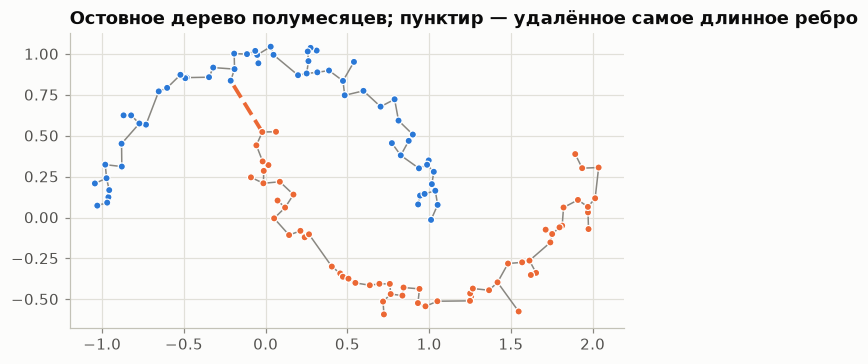

In [18]:
N8 = "ABCDEFGH"
E8 = [(0, 1, 4), (0, 4, 7), (1, 2, 8), (1, 5, 3), (0, 5, 6), (2, 3, 5), (2, 6, 2), (3, 7, 9), (4, 5, 10), (5, 6, 1), (6, 7, 11), (3, 6, 12), (1, 4, 13), (2, 5, 14)]
par = list(range(8))


def find(v):
    while par[v] != v:
        par[v] = par[par[v]]
        v = par[v]
    return v


mst = []
for a, b, w in sorted(E8, key=lambda e: e[2]):
    if find(a) != find(b):
        par[find(a)] = find(b)
        mst.append((N8[a] + N8[b], w))
W8 = np.zeros((8, 8))
for a, b, w in E8:
    W8[a, b] = w
assert sum(w for _, w in mst) == minimum_spanning_tree(csr_matrix(W8)).sum() == 31
print("Краскал:", mst, "вес 31")

from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import AgglomerativeClustering

Xm, ym = datasets.classification_2d(kind="moons", n=120, noise=0.06, seed=3)
T = minimum_spanning_tree(squareform(pdist(Xm))).tocoo()
keep = np.ones(len(T.data), bool)
keep[np.argsort(-T.data)[:1]] = False
_, lab = connected_components(csr_matrix((T.data[keep], (T.row[keep], T.col[keep])), shape=T.shape), directed=False)
sk = AgglomerativeClustering(n_clusters=2, linkage="single").fit_predict(Xm)
agree = max(np.mean(lab == sk), np.mean(lab != sk))
print("размеры кластеров:", np.bincount(lab), " совпадение со sklearn single linkage:", agree, " с истинными полумесяцами:", max(np.mean(lab == ym), np.mean(lab != ym)))
assert agree == 1.0

fig, ax = plt.subplots(figsize=(6.5, 3.6))
for i, j, w in zip(T.row, T.col, T.data):
    ax.plot(*zip(Xm[i], Xm[j]), color=MUTED if keep[list(T.data).index(w)] else ORANGE, lw=1 if keep[list(T.data).index(w)] else 2.5, ls="-" if keep[list(T.data).index(w)] else "--")
ax.scatter(*Xm.T, c=[SERIES[c] for c in lab], s=22, edgecolors="white", linewidths=0.8, zorder=3)
ax.set_aspect("equal")
ax.set_title("Остовное дерево полумесяцев; пунктир — удалённое самое длинное ребро")
plt.show()

## Блок 4. Ориентированные графы

Топологическая сортировка (Кан), критический путь и сильно связные компоненты (сверка со scipy).

In [19]:
def kahn(n, edges):
    indeg = [0] * n
    for _, b in edges:
        indeg[b] += 1
    q, order = deque(i for i in range(n) if indeg[i] == 0), []
    while q:
        v = q.popleft()
        order.append(v)
        for a, b in edges:
            if a == v:
                indeg[b] -= 1
                if indeg[b] == 0:
                    q.append(b)
    return order


tasks = ["сбор данных", "разметка", "очистка", "признаки", "базовая модель", "бустинг", "подбор параметров", "отчёт"]
dur = [3, 4, 2, 3, 1, 2, 4, 1]
deps = [(0, 1), (0, 2), (2, 3), (1, 4), (2, 4), (3, 5), (1, 5), (5, 6), (4, 7), (6, 7)]
order = kahn(8, deps)
ES = [0] * 8
for v in order:
    for a, b in deps:
        if a == v:
            ES[b] = max(ES[b], ES[v] + dur[v])
T_total = max(ES[i] + dur[i] for i in range(8))
LF = [T_total] * 8
for v in reversed(order):
    for a, b in deps:
        if a == v:
            LF[a] = min(LF[a], LF[b] - dur[b])
slack = [LF[i] - dur[i] - ES[i] for i in range(8)]
print("срок:", T_total, " резервы:", dict(zip(tasks, slack)))
assert T_total == 15 and slack[1] == 1 and slack[4] == 6

pipeline = [(0, 1), (1, 2), (1, 3), (2, 4), (3, 4), (4, 5), (4, 6), (5, 6), (6, 7), (5, 7)]
print("конвейер упорядочен:", len(kahn(8, pipeline)) == 8, "; с циклом валидация → признаки:", len(kahn(8, pipeline + [(6, 2)])) == 8)

scc_edges = [(0, 1), (1, 2), (2, 0), (2, 3), (3, 4), (4, 5), (5, 3), (5, 6), (6, 7), (7, 6), (4, 8), (1, 8)]
Ms = np.zeros((9, 9))
for a, b in scc_edges:
    Ms[a, b] = 1
k, lab = connected_components(csr_matrix(Ms), directed=True, connection="strong")
print("сильно связных компонент:", k, sorted(sorted(int(i) + 1 for i in np.flatnonzero(lab == c)) for c in range(k)))
Ms[8, 0] = 1
print("после стрелки 9 → 1:", connected_components(csr_matrix(Ms), directed=True, connection="strong")[0])

срок: 15  резервы: {'сбор данных': 0, 'разметка': 1, 'очистка': 0, 'признаки': 0, 'базовая модель': 6, 'бустинг': 0, 'подбор параметров': 0, 'отчёт': 0}
конвейер упорядочен: True ; с циклом валидация → признаки: False
сильно связных компонент: 4 [[1, 2, 3], [4, 5, 6], [7, 8], [9]]
после стрелки 9 → 1: 2


## Блок 5. Раскраска, паросочетания, потоки

### 5.1. Жадная раскраска: порядок решает

Корона на 8 вершинах двудольна, но порядок $u_1, v_1, u_2, v_2, \ldots$ даёт 4 цвета.

In [20]:
def greedy(n, E, order):
    S = adj_sets(n, E)
    color = {}
    for v in order:
        used = {color[u] for u in S[v] if u in color}
        color[v] = next(c for c in range(n) if c not in used)
    return max(color.values()) + 1


def chromatic(n, E):
    return next(k for k in range(1, n + 1) if any(all(c[a] != c[b] for a, b in E) for c in product(range(k), repeat=n)))


crown = [(i, 4 + j) for i in range(4) for j in range(4) if i != j]
print("корона: плохой порядок", greedy(8, crown, [0, 4, 1, 5, 2, 6, 3, 7]), "цвета, хороший", greedy(8, crown, range(8)), "; χ =", chromatic(8, crown))
print("χ(Петерсен) =", chromatic(10, petersen), "; χ(W5) =", chromatic(6, [(0, i) for i in range(1, 6)] + [(i, i % 5 + 1) for i in range(1, 6)]))

корона: плохой порядок 4 цвета, хороший 2 ; χ = 2
χ(Петерсен) = 3 ; χ(W5) = 4


### 5.2. Формула Эйлера и неравенство $|E| \le 3|V| - 6$

In [21]:
for name, V, Ecnt, F in (("тетраэдр", 4, 6, 4), ("куб", 8, 12, 6), ("октаэдр", 6, 12, 8), ("призма", 6, 9, 5)):
    print(f"{name:9} V − E + F = {V} − {Ecnt} + {F} = {V - Ecnt + F};  E ≤ 3V − 6: {Ecnt} ≤ {3 * V - 6}")
print("K5: E = 10 > 3·5 − 6 = 9;  K33: E = 9 > 2·6 − 4 = 8 — не планарны")

тетраэдр  V − E + F = 4 − 6 + 4 = 2;  E ≤ 3V − 6: 6 ≤ 6
куб       V − E + F = 8 − 12 + 6 = 2;  E ≤ 3V − 6: 12 ≤ 18
октаэдр   V − E + F = 6 − 12 + 8 = 2;  E ≤ 3V − 6: 12 ≤ 12
призма    V − E + F = 6 − 9 + 5 = 2;  E ≤ 3V − 6: 9 ≤ 12
K5: E = 10 > 3·5 − 6 = 9;  K33: E = 9 > 2·6 − 4 = 8 — не планарны


### 5.3. Паросочетания (Кун) и потоки (Форд — Фалкерсон)

In [22]:
def kuhn(adj_r):
    match = [-1] * 5

    def try_k(u, seen):
        for t in adj_r[u]:
            if t not in seen:
                seen.add(t)
                if match[t] < 0 or try_k(match[t], seen):
                    match[t] = u
                    return True
        return False

    return sum(try_k(u, set()) for u in range(len(adj_r)))


for name, adj_r in (("всех можно занять", [[0, 1], [0], [1, 2, 3], [2, 4], [3]]), ("нарушен Холл", [[0, 1], [0], [0, 1], [2, 3, 4], [3]])):
    B = np.zeros((5, 5))
    for u, ts in enumerate(adj_r):
        B[u, ts] = 1
    sp = int((maximum_bipartite_matching(csr_matrix(B), perm_type="column") >= 0).sum())
    print(f"{name}: Кун {kuhn(adj_r)}, scipy {sp}")
    assert kuhn(adj_r) == sp

cap = np.zeros((6, 6), dtype=np.int32)
for u, v, c in [(0, 1, 10), (0, 2, 8), (1, 2, 3), (1, 3, 6), (2, 4, 9), (3, 5, 8), (4, 5, 10), (4, 3, 2)]:
    cap[u, v] = c
flow = maximum_flow(csr_matrix(cap), 0, 5).flow_value
print("максимальный поток:", flow, "= разрез a→c (6) + b→d (9)")
assert flow == 15

всех можно занять: Кун 5, scipy 5
нарушен Холл: Кун 4, scipy 4
максимальный поток: 15 = разрез a→c (6) + b→d (9)


## Блок 6. Графы и матрицы

Маршруты через степени матрицы, PageRank двумя способами, центральность Брандеса против прямого подсчёта
кратчайших путей, спектр лапласиана, распространение меток.

In [23]:
A5 = np.zeros((5, 5), dtype=int)
for a, b in [(0, 1), (0, 2), (1, 2), (2, 3), (2, 4), (3, 4)]:
    A5[a, b] = A5[b, a] = 1
print("диагональ A²:", np.diag(A5 @ A5), " треугольников:", np.trace(np.linalg.matrix_power(A5, 3)) // 6,
      " маршрутов длины 3 и 4:", np.linalg.matrix_power(A5, 3).sum(), np.linalg.matrix_power(A5, 4).sum())

pr_names = "ABCDEF"
out = {"A": "BC", "B": "C", "C": "A", "D": "C", "E": "CD", "F": "AE"}
Mp = np.zeros((6, 6))
for a, bs in out.items():
    for b in bs:
        Mp[pr_names.index(b), pr_names.index(a)] = 1 / len(bs)
for d in (0.5, 0.85, 0.95):
    r, it = np.full(6, 1 / 6), 0
    while True:
        nr = (1 - d) / 6 + d * Mp @ r
        it += 1
        if np.abs(nr - r).sum() < 1e-4:
            break
        r = nr
    Gm = d * Mp + (1 - d) / 6
    vals, vecs = np.linalg.eig(Gm)
    v = np.real(vecs[:, np.argmax(np.real(vals))])
    print(f"d = {d}: PageRank {dict(zip(pr_names, nr.round(3)))}, итераций {it}; собственный вектор совпадает: {np.allclose(v / v.sum(), nr, atol=1e-4)}")

rng = Mulberry32(1)
cnt, v = np.zeros(6), rng.randint(6)
for _ in range(30000):
    v = pr_names.index(out[pr_names[v]][rng.randint(len(out[pr_names[v]]))]) if rng.random() < 0.85 else rng.randint(6)
    cnt[v] += 1
print("блуждание 30 000 шагов:", dict(zip(pr_names, (cnt / 30000).round(3))))

диагональ A²: [2 2 4 2 2]  треугольников: 2  маршрутов длины 3 и 4: 80 208
d = 0.5: PageRank {'A': np.float64(0.255), 'B': np.float64(0.147), 'C': np.float64(0.301), 'D': np.float64(0.109), 'E': np.float64(0.104), 'F': np.float64(0.083)}, итераций 9; собственный вектор совпадает: True
d = 0.85: PageRank {'A': np.float64(0.352), 'B': np.float64(0.175), 'C': np.float64(0.372), 'D': np.float64(0.04), 'E': np.float64(0.036), 'F': np.float64(0.025)}, итераций 17; собственный вектор совпадает: True
d = 0.95: PageRank {'A': np.float64(0.384), 'B': np.float64(0.191), 'C': np.float64(0.391), 'D': np.float64(0.014), 'E': np.float64(0.012), 'F': np.float64(0.008)}, итераций 24; собственный вектор совпадает: True
блуждание 30 000 шагов: {'A': np.float64(0.352), 'B': np.float64(0.173), 'C': np.float64(0.374), 'D': np.float64(0.041), 'E': np.float64(0.036), 'F': np.float64(0.025)}


In [24]:
CGe = [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 4), (2, 4), (4, 5), (5, 6), (6, 7), (7, 8), (7, 9), (8, 9), (8, 10), (9, 10), (10, 11), (9, 11)]
Wc = np.zeros((12, 12))
for a, b in CGe:
    Wc[a, b] = Wc[b, a] = 1
Dc = floyd_warshall(Wc, directed=False)
Sc = adj_sets(12, CGe)


def sigma_from(s):
    dist, sig, q = {s: 0}, {s: 1}, deque([s])
    while q:
        v = q.popleft()
        for u in Sc[v]:
            if u not in dist:
                dist[u], sig[u] = dist[v] + 1, 0
                q.append(u)
            if dist[u] == dist[v] + 1:
                sig[u] += sig[v]
    return sig


SIG = [sigma_from(s) for s in range(12)]
btw = []
for v in range(12):
    tot = 0.0
    for s in range(12):
        for t in range(s + 1, 12):
            if v not in (s, t) and Dc[s, v] + Dc[v, t] == Dc[s, t]:
                tot += SIG[s][v] * SIG[v][t] / SIG[s][t]
    btw.append(tot / comb(11, 2))
clo = (11 / Dc.sum(1)).round(3)
print("посредничество (прямой подсчёт σ):", np.round(btw, 3))
print("близость:", clo)
assert abs(btw[5] - 30 / 55) < 1e-12

посредничество (прямой подсчёт σ): [0.    0.009 0.227 0.073 0.509 0.545 0.545 0.509 0.073 0.227 0.009 0.   ]
близость: [0.25  0.256 0.314 0.306 0.367 0.393 0.393 0.367 0.306 0.314 0.256 0.25 ]


In [25]:
L6 = np.zeros((6, 6))
for i, j in [(0, 1), (1, 2), (0, 2), (3, 4), (4, 5), (3, 5), (2, 3)]:
    L6[i, j] = L6[j, i] = -1
L6 += np.diag(-L6.sum(1))
vals, vecs = np.linalg.eigh(L6)
print("спектр лапласиана двух треугольников с мостиком:", vals.round(3), " знак Фидлера:", (vecs[:, 1] > 0).astype(int))

rng = Mulberry32(3)
truth = np.array([0] * 10 + [1] * 10)
Ap = np.zeros((20, 20))
for i in range(20):
    for j in range(i + 1, 20):
        if rng.random() < (0.45 if truth[i] == truth[j] else 0.04):
            Ap[i, j] = Ap[j, i] = 1
labels = {0: 0, 4: 0, 10: 1, 15: 1}
f = np.array([labels.get(i, 0.5) for i in range(20)], float)
free = np.array([i not in labels and Ap[i].sum() > 0 for i in range(20)])
for _ in range(30):
    f = np.where(free, Ap @ f / np.maximum(Ap.sum(1), 1), f)
unl = np.array([i not in labels for i in range(20)])
print("распространение меток: верно у неразмеченных", round(((f > 0.5) == truth)[unl].mean(), 3))

спектр лапласиана двух треугольников с мостиком: [0.    0.438 3.    3.    3.    4.562]  знак Фидлера: [0 0 0 1 1 1]
распространение меток: верно у неразмеченных 0.812


## Блок 7. Случайные и реальные сети

Гигантская компонента: моделирование против уравнения $s = 1 - e^{-cs}$; тесный мир; хабы Барабаши — Альберт.

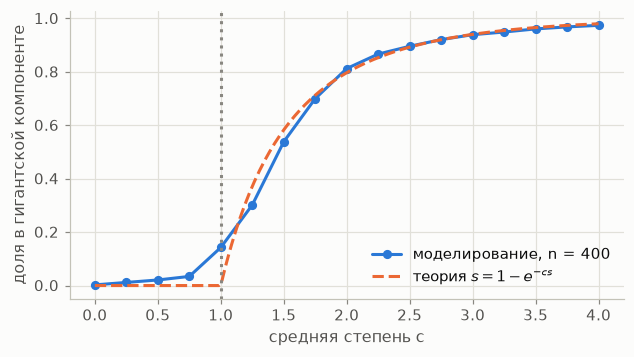

{1.5: np.float64(0.583), 2: np.float64(0.797), 3: np.float64(0.94)}


In [26]:
def giant(n, c, seed):
    rng = Mulberry32(seed)
    par = list(range(n))

    def fnd(v):
        while par[v] != v:
            par[v] = par[par[v]]
            v = par[v]
        return v

    p = c / (n - 1)
    for i in range(n):
        for j in range(i + 1, n):
            if rng.random() < p:
                par[fnd(i)] = fnd(j)
    return np.bincount([fnd(i) for i in range(n)]).max() / n


cs = np.linspace(0, 4, 17)
sim = [np.mean([giant(400, c, 100 + k) for k in range(3)]) for c in cs]


def theory(c):
    s = 1.0
    for _ in range(2000):
        s = 1 - np.exp(-c * s)
    return s


fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(cs, sim, color=BLUE, marker="o", label="моделирование, n = 400")
cc = np.linspace(0, 4, 200)
ax.plot(cc, [theory(c) for c in cc], color=ORANGE, ls="--", label="теория $s = 1 - e^{-cs}$")
ax.axvline(1, color=MUTED, ls=":")
ax.set_xlabel("средняя степень c")
ax.set_ylabel("доля в гигантской компоненте")
ax.legend()
plt.show()
print({c: round(theory(c), 3) for c in (1.5, 2, 3)})

In [27]:
def watts_strogatz(n, k, p, seed):
    rng = Mulberry32(seed)
    adj = [set() for _ in range(n)]
    edges = [(i, (i + j) % n) for i in range(n) for j in range(1, k // 2 + 1)]
    for i, u in edges:
        adj[i].add(u)
        adj[u].add(i)
    for i, u in edges:
        if rng.random() < p:
            for _ in range(100):
                c = rng.randint(n)
                if c != i and c not in adj[i]:
                    adj[i].discard(u)
                    adj[u].discard(i)
                    adj[i].add(c)
                    adj[c].add(i)
                    break
    return adj


def clustering_and_L(adj):
    cs_, tot, cnt = [], 0, 0
    for a in adj:
        a = sorted(a)
        k = len(a)
        cs_.append(sum(a[y] in adj[a[x]] for x in range(k) for y in range(x + 1, k)) / (k * (k - 1) / 2) if k > 1 else 0)
    for s in range(len(adj)):
        d, q = {s: 0}, deque([s])
        while q:
            v = q.popleft()
            for u in adj[v]:
                if u not in d:
                    d[u] = d[v] + 1
                    q.append(u)
        tot += sum(d.values())
        cnt += len(d) - 1
    return np.mean(cs_), tot / cnt


base = [clustering_and_L(watts_strogatz(100, 6, 0, 10 + s)) for s in range(6)]
C0, L0 = np.mean([b[0] for b in base]), np.mean([b[1] for b in base])
for p in (0.01, 0.05, 1):
    r = [clustering_and_L(watts_strogatz(100, 6, p, 10 + s)) for s in range(6)]
    print(f"p = {p:<5} C/C0 = {np.mean([x[0] for x in r]) / C0:.2f}, L/L0 = {np.mean([x[1] for x in r]) / L0:.2f}")

p = 0.01  C/C0 = 0.97, L/L0 = 0.75
p = 0.05  C/C0 = 0.86, L/L0 = 0.49
p = 1     C/C0 = 0.10, L/L0 = 0.31


максимальная степень: БА 79  ЭР 11


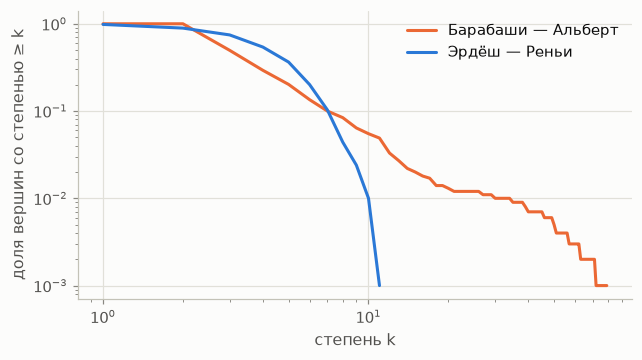

In [28]:
def barabasi(n, m, seed):
    rng = Mulberry32(seed)
    edges, rep = [(0, 1), (0, 2), (1, 2)], [0, 1, 0, 2, 1, 2]
    for v in range(3, n):
        tg = set()
        while len(tg) < m:
            tg.add(rep[rng.randint(len(rep))])
        for u in sorted(tg):
            edges.append((u, v))
            rep += [u, v]
    return edges


Eba = barabasi(1000, 2, 1)
deg_ba = np.bincount(np.array(Eba).ravel(), minlength=1000)
rng = Mulberry32(1)
p_er = 2 * len(Eba) / (1000 * 999)
Eer = [(i, j) for i in range(1000) for j in range(i + 1, 1000) if rng.random() < p_er]
deg_er = np.bincount(np.array(Eer).ravel(), minlength=1000)
print("максимальная степень: БА", deg_ba.max(), " ЭР", deg_er.max())
fig, ax = plt.subplots(figsize=(6.5, 3.4))
for deg, c, name in ((deg_ba, ORANGE, "Барабаши — Альберт"), (deg_er, BLUE, "Эрдёш — Реньи")):
    ks = np.arange(1, deg.max() + 1)
    ax.loglog(ks, [(deg >= k).mean() for k in ks], color=c, label=name)
ax.set_xlabel("степень k")
ax.set_ylabel("доля вершин со степенью ≥ k")
ax.legend()
plt.show()

## Блок 8. Графы в бустинге

### 8.1. Графовые признаки, утечка и разбиение по сообществам

Тот же генератор графа переводов, что в виджетах. Среднее по 10 графам: свои признаки, графовые,
графовые с утечкой; затем — разбиение по сообществам.

In [29]:
def fraud_graph(seed):
    rng = Mulberry32(seed)
    n = 400
    comm, fraud, x1, x2 = [], [], [], []
    for i in range(n):
        comm.append(rng.randint(6))
        fraud.append(1 if rng.random() < (0.6 if comm[i] < 2 else 0.04) else 0)
        x1.append(rng.normal(0.7 if fraud[i] else 0, 1))
        x2.append(rng.normal(0, 1))
    nb = [[] for _ in range(n)]
    for i in range(n):
        for j in range(i + 1, n):
            if rng.random() < (0.08 if comm[i] == comm[j] else 0.003):
                nb[i].append(j)
                nb[j].append(i)
    perm = rng.permutation(n)
    train = [False] * n
    for i in perm[:240]:
        train[i] = True
    return dict(n=n, comm=comm, fraud=fraud, x1=x1, x2=x2, nb=nb, train=train)


def auc(Gf, train, cols, leak=False):
    F = []
    for i in range(Gf["n"]):
        tr = [j for j in Gf["nb"][i] if train[j]]
        ft = sum(Gf["fraud"][j] for j in tr)
        if leak:
            fa = sum(Gf["fraud"][j] for j in Gf["nb"][i])
            F.append([Gf["x1"][i], Gf["x2"][i], len(Gf["nb"][i]), len(tr), fa, fa / max(1, len(Gf["nb"][i]))])
        else:
            F.append([Gf["x1"][i], Gf["x2"][i], len(Gf["nb"][i]), len(tr), ft, ft / max(1, len(tr))])
    tri = [i for i in range(Gf["n"]) if train[i]]
    te = [i for i in range(Gf["n"]) if not train[i]]
    m = GBClassifier(n_estimators=60, learning_rate=0.05, max_depth=2, min_samples_leaf=10)
    m.fit([[F[i][c] for c in cols] for i in tri], [Gf["fraud"][i] for i in tri])
    return roc_auc([Gf["fraud"][i] for i in te], m.predict_proba([[F[i][c] for c in cols] for i in te])[:, 1])


OWN, ALL = [0, 1], list(range(6))
rows = []
for seed in range(7, 17):
    Gf = fraud_graph(seed)
    ct = [c in (0, 2, 3) for c in Gf["comm"]]
    rows.append([auc(Gf, Gf["train"], OWN), auc(Gf, Gf["train"], ALL), auc(Gf, Gf["train"], ALL, leak=True), auc(Gf, ct, OWN), auc(Gf, ct, ALL)])
rows = np.array(rows)
print("средний ROC AUC по 10 графам:")
for name, v in zip(["случайное: свои", "случайное: + графовые", "случайное: + утечка", "по сообществам: свои", "по сообществам: + графовые"], rows.mean(0)):
    print(f"  {name:28} {v:.3f}")
assert rows[:, 1].mean() > rows[:, 0].mean() + 0.1 and rows[:, 2].mean() > rows[:, 1].mean()
assert rows[:, 4].mean() - rows[:, 3].mean() < rows[:, 1].mean() - rows[:, 0].mean()

средний ROC AUC по 10 графам:
  случайное: свои              0.647
  случайное: + графовые        0.814
  случайное: + утечка          0.846
  по сообществам: свои         0.629
  по сообществам: + графовые   0.603


### 8.2. Граф взаимодействий признаков: пути деревьев против H-статистики

Данные Фридмана: $y = 10\sin(\pi x_1 x_2) + 20(x_3 - 0.5)^2 + 10x_4 + 5x_5 + \varepsilon$. Совместное
появление признаков на путях деревьев смещено к важному $x_4$; H-статистика находит настоящую пару
$x_1$–$x_2$. Сверим со структурой деревьев XGBoost той же глубины.

In [30]:
def path_pairs(trees_nodes, d):
    S = np.zeros((d, d))

    def walk(nodes, i, anc):
        nd = nodes[i]
        if nd.left < 0:
            return
        for f_ in anc:
            if f_ != nd.feature:
                S[f_, nd.feature] += nd.gain
                S[nd.feature, f_] += nd.gain
        walk(nodes, nd.left, anc + [nd.feature])
        walk(nodes, nd.right, anc + [nd.feature])

    for nodes in trees_nodes:
        walk(nodes, 0, [])
    return S


def h_stat(model, X):
    bg, pts = X[:60], X[200:225]
    fp = model.predict(pts)
    var = ((fp - fp.mean()) ** 2).sum()

    def pd(cols):
        o = []
        for p in pts:
            Z = bg.copy()
            Z[:, cols] = p[cols]
            o.append(model.predict(Z).mean())
        o = np.array(o)
        return o - o.mean()

    single = [pd([j]) for j in range(X.shape[1])]
    Hm = np.zeros((X.shape[1],) * 2)
    for a in range(X.shape[1]):
        for b in range(a + 1, X.shape[1]):
            Hm[a, b] = ((pd([a, b]) - single[a] - single[b]) ** 2).sum() / var
    return Hm


top = lambda M: sorted(((M[a, b], f"x{a + 1}–x{b + 1}") for a in range(10) for b in range(a + 1, 10)), reverse=True)[:3]
for depth in (1, 3):
    m = GBRegressor(n_estimators=80, learning_rate=0.1, max_depth=depth, min_samples_leaf=5).fit(Xf, yf)
    S = path_pairs([t.nodes for stage in m.trees_ for t in stage], 10)
    Hm = h_stat(m, Xf)
    tot = S.sum() / 2 or 1
    print(f"глубина {depth}: R² = {1 - ((yf - m.predict(Xf)) ** 2).mean() / yf.var():.3f}")
    print("   вместе на пути:", [(n_, round(v / tot, 3)) for v, n_ in top(S)])
    print("   H²:            ", [(n_, round(v, 4)) for v, n_ in top(Hm)])
    if depth == 3:
        assert top(S)[0][1] != "x1–x2" and top(Hm)[0][1] == "x1–x2"

xm = xgb.XGBRegressor(n_estimators=80, learning_rate=0.1, max_depth=3, tree_method="exact").fit(Xf, yf)
tdf = xm.get_booster().trees_to_dataframe()
Sx = np.zeros((10, 10))


def walkx(rows_x, nid, anc):
    r_ = rows_x.loc[nid]
    if r_.Feature == "Leaf":
        return
    f_ = int(r_.Feature[1:])
    for a in anc:
        if a != f_:
            Sx[a, f_] += r_.Gain
            Sx[f_, a] += r_.Gain
    walkx(rows_x, r_.Yes, anc + [f_])
    walkx(rows_x, r_.No, anc + [f_])


for _, tr in tdf.groupby("Tree"):
    walkx(tr.set_index("ID"), f"{tr.Tree.iloc[0]}-0", [])
print("XGBoost, вместе на пути:", [(n_, round(v / (Sx.sum() / 2), 3)) for v, n_ in top(Sx)])

глубина 1: R² = 0.791
   вместе на пути: [('x9–x10', np.float64(0.0)), ('x8–x9', np.float64(0.0)), ('x8–x10', np.float64(0.0))]
   H²:             [('x3–x4', np.float64(0.0)), ('x1–x5', np.float64(0.0)), ('x1–x4', np.float64(0.0))]


глубина 3: R² = 0.970
   вместе на пути: [('x1–x4', np.float64(0.248)), ('x2–x4', np.float64(0.216)), ('x1–x2', np.float64(0.197))]
   H²:             [('x1–x2', np.float64(0.0117)), ('x1–x4', np.float64(0.0058)), ('x2–x4', np.float64(0.0031))]
XGBoost, вместе на пути: [('x1–x4', np.float64(0.247)), ('x2–x4', np.float64(0.218)), ('x1–x2', np.float64(0.204))]


## Упражнения

Задания — в `exercises/tasks.md`, решения — в `exercises/solutions.py`:

1. Рукопожатия и степенные последовательности ★☆☆
2. Узлы и рёбра дерева с L листьями ★☆☆
3. Двудольность одним BFS ★★☆
4. Краскал с системой непересекающихся множеств ★★☆
5. Маршруты: степени матрицы против динамики ★★☆
6. Код Прюфера и формула Кэли ★★☆
7. Посредничество: Брандес против прямого подсчёта ★★☆
8. A* против Дейкстры на случайном лабиринте ★★☆
9. Арбитраж Беллманом — Фордом ★★★
10. Критический путь и резервы ★★☆
11. Честная проверка графовых признаков ★★★
12. Взаимодействия признаков: пути против H-статистики ★★★